In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
from firedrake import *
import matplotlib.pyplot as plt

import numpy as np

# Ex.1 - Stokes problem - patch test

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,3)\times(0,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
(\nabla\boldsymbol{u}-pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_1\cup\Gamma_2,\\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \Gamma_3, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4.
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D} = 1\boldsymbol{i}$.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?


firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


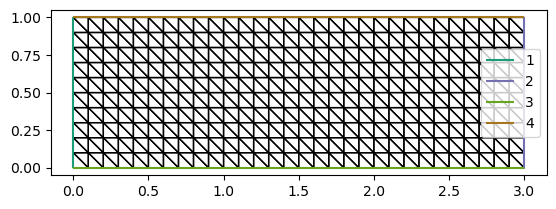

In [4]:
# Build the mesh
n = 10
mesh = RectangleMesh(3*n, n, 3, 1)

fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.set_aspect("equal")

In [11]:
# Function spaces

# P1-P0
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'DP', 0) # NB: P0 are DISCONTINUOUS elements (DP)

# # P1-P1
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'P', 1)

# # P1b-P1
# # The enrichment of the velocity space has to be done at the finite element level
# V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
# B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension() + 1)
# V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
# V = FunctionSpace(mesh, V_el)
# Q = FunctionSpace(mesh, 'P', 1)

# # P2-P1
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)

W = MixedFunctionSpace([V, Q])
print('Ndofs - velocity :',V.dim(),', pressure :',Q.dim(),', total :',W.dim())

# Finite element functions
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

Ndofs - velocity : 2562 , pressure : 341 , total : 2903


In [12]:
# Boundary conditions (strong)
bc3 = DirichletBC(W.sub(0), Constant((0., 0.)), 3)
bc4 = DirichletBC(W.sub(0), Constant((1., 0.)), 4)
bcs = (bc3, bc4)

# Variational formulation
a = inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
L = inner(Constant((0.0,0.0)), v) * dx
  # Dummy rhs (=0) to ensure that the solve recognize a==L as a linear problem

# Solution (NB: do not use the same name u,v,p,q of the trial/test functions)
wh = Function(W)
solve(a == L, wh, bcs=bcs)
uh, ph = wh.subfunctions

Text(0.5, 1.0, 'velocity')

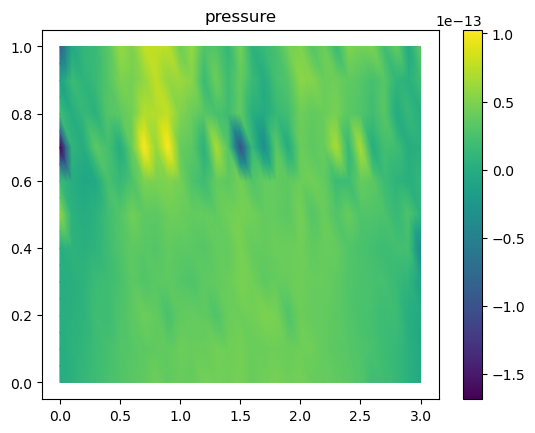

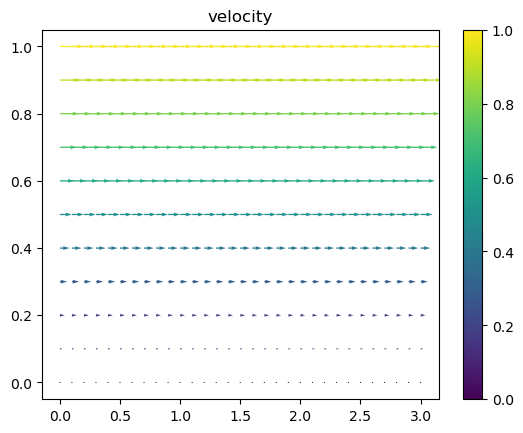

In [13]:
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')

In [ ]:
# Error computation
x = SpatialCoordinate(mesh)
u_ex = as_vector([x[1],0.])
grad_u_ex = as_tensor([[0.,1.],[0.,0.]])
p_ex = Constant(0.)
errL2u = errornorm(u_ex, uh, 'L2')
errL2p = errornorm(p_ex, ph, 'L2')
print('Errors - L2-u:', errL2u, ', L2-p:', errL2p)
# errornorm does not have the 'H1' seminorm (H10), but only the full H1 norm
errH1u = errornorm(u_ex, uh, 'H1')
print('Errors - H1-u:', errH1u)

# Alternative: explicitly assemble integrals.
# Notice that integrands contains only Functions and no Trial/TestFunctions:
#         in this way, its assembling returns a single number (as expected)
#         and not a bilinear/linear form.
errL2u = sqrt(assemble( inner(uh-u_ex,uh-u_ex) * dx ))
errH10u = sqrt(assemble( inner(grad(uh)-grad_u_ex,grad(uh)-grad_u_ex) * dx ))
errL2p = sqrt(assemble( inner(ph-p_ex,ph-p_ex) * dx ))
print('Errors - L2-u:', errL2u, ', H10-u:', errH10u, ', L2-p:', errL2p)

# Ex.2 - Stokes problem - Block algebraic formulation

\begin{equation*}
\begin{cases}
- \mu\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,2)\times(-1,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \Gamma_\text{wall}=\{0\leq x\leq2, y\in\{-1,1\}\}, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_\text{in}=\{x=0,-1\leq y\leq 1\},\\
(\nabla\boldsymbol{u}-pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_\text{out}=\{x=2,-1\leq y\leq 1\},\\
\end{cases}
\end{equation*}

with $\mu=10^{-2}$ and $\boldsymbol{g}_\text{D} = (1-y^2)\boldsymbol{i}$.

In [ ]:
# Build domain mesh - y_min=-1
n = 2
mesh = RectangleMesh(2*n, 2*n, 2., 1., originY=-1.)

fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()

In [ ]:
from time import perf_counter

# Function spaces
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Boundary conditions
x = SpatialCoordinate(mesh)
gD = (1.-x[1]**2, 0.)
bc_in = DirichletBC(W.sub(0), gD, 1)
bc_wall = DirichletBC(W.sub(0), Constant((0.,0.)), (3, 4))
bcs = (bc_in, bc_wall)

# Variational formulation
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
f = Constant((0.,0.))

a = 1e-2*inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
L = dot(f, v) * dx

# Solution
wh = Function(W)

# equiv. solve(a==L,wh,bcs=bcs)
vpb = LinearVariationalProblem(a, L, wh, bcs)

parameters = {'ksp_type': 'preonly', "pc_type": "lu",
                             "pc_factor_mat_solver_type": "mumps"}
solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)
t0 = perf_counter()
solver.solve()
print('Ndofs =', W.dim(), ' -  elapsed time = ', perf_counter() - t0, 's  -  # iter = ', solver.snes.ksp.getIterationNumber())

In [ ]:
uh, ph = wh.subfunctions
fig, ax = plt.subplots()
q = tripcolor(ph, axes=ax)
plt.colorbar(q)
fig, ax = plt.subplots()
q = quiver(uh, axes=ax)
plt.colorbar(q)

In [ ]:
# from Firedrake Matrix object (output of assemble of bilinear form) to numpy array
def mat2numpy(A):
  return A.petscmat.getValues(range(0, A.petscmat.getSize()[0]), range(0,  A.petscmat.getSize()[1]))

fig, (ax1, ax2) = plt.subplots(1, 2)
A = assemble(a)
Anumpy = mat2numpy(A)
ax1.spy(Anumpy)
ax1.title.set_text('nnz = '+str(np.count_nonzero(Anumpy)))
A = assemble(a, bcs=bcs)
Anumpy = mat2numpy(A)
ax2.spy(Anumpy)
ax2.title.set_text('nnz = '+str(np.count_nonzero(Anumpy)))

# (additional) Fully Dirichlet problem and null space

Dimension of the computed nullspace =  1
4 smallest eigenvalues =  [1.35577776e-16 3.93640421e-04 4.08702846e-04 1.32844375e-03]


Text(0.5, 1.0, 'Eigenmode associated to eigenvalue "0" (1.35577776406846e-16)\n')

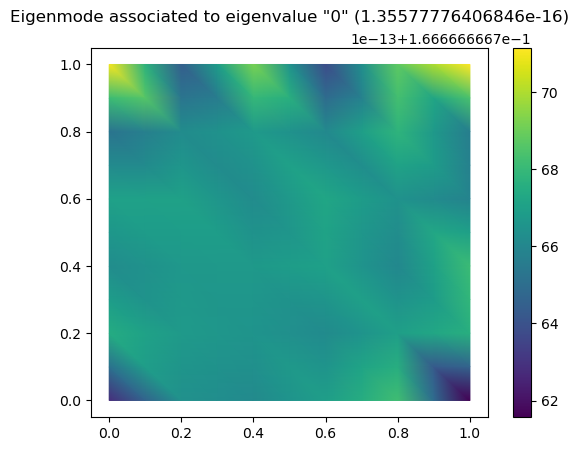

In [14]:
u_ex_fun = lambda x: as_vector((
    -cos(x[0]) * sin(x[1]),
    sin(x[0]) * cos(x[1])))
p_ex_fun = lambda x: -0.25 * (cos(2*x[0]) + cos(2*x[1])) + 0.25*sin(2.0)
f_fun = lambda x: as_vector((
    -2 * cos(x[0]) * sin(x[1]) + 0.5 * sin(2 * x[0]),
    2 * sin(x[0]) * cos(x[1]) + 0.5 * sin(2 * x[1])))

# Small problem to investigate eigenvalues
n=5
mesh = UnitSquareMesh(n, n, 'crossed')
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])
x = SpatialCoordinate(mesh)
gD = u_ex_fun(x)
f = f_fun(x)
bc = DirichletBC(W.sub(0), gD, 'on_boundary')
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
a = inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx

# Monolithic matrix
Sigma = assemble(a, bcs=(bc)).M.values   # .M.values   :  from Firedrake to numpy matrix

w, vv = np.linalg.eig(Sigma)
true_nullspace = vv[:, abs(w)<1e-14]

print('Dimension of the computed nullspace = ', true_nullspace.shape[1])
sorted_w = np.sort(w)
print('4 smallest eigenvalues = ', sorted_w[0:4])

# Plot eigenmode
Qdim = Q.dim() #dimension of pressure space
ps = Function(Q, val=true_nullspace[-Qdim:,0]) # Last Qdim entries
# see https://www.firedrakeproject.org/firedrake.html#firedrake.function.Function
fig, ax = plt.subplots()
q = tripcolor(ps, axes=ax)
plt.colorbar(q)
plt.title('Eigenmode associated to eigenvalue "0" ('+str(sorted_w[0])+')\n')
